In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import math
import utilities

### Distribution of Ending Wealth for Dice Rolls

All in vs. 60% cash vs. 9% insurance

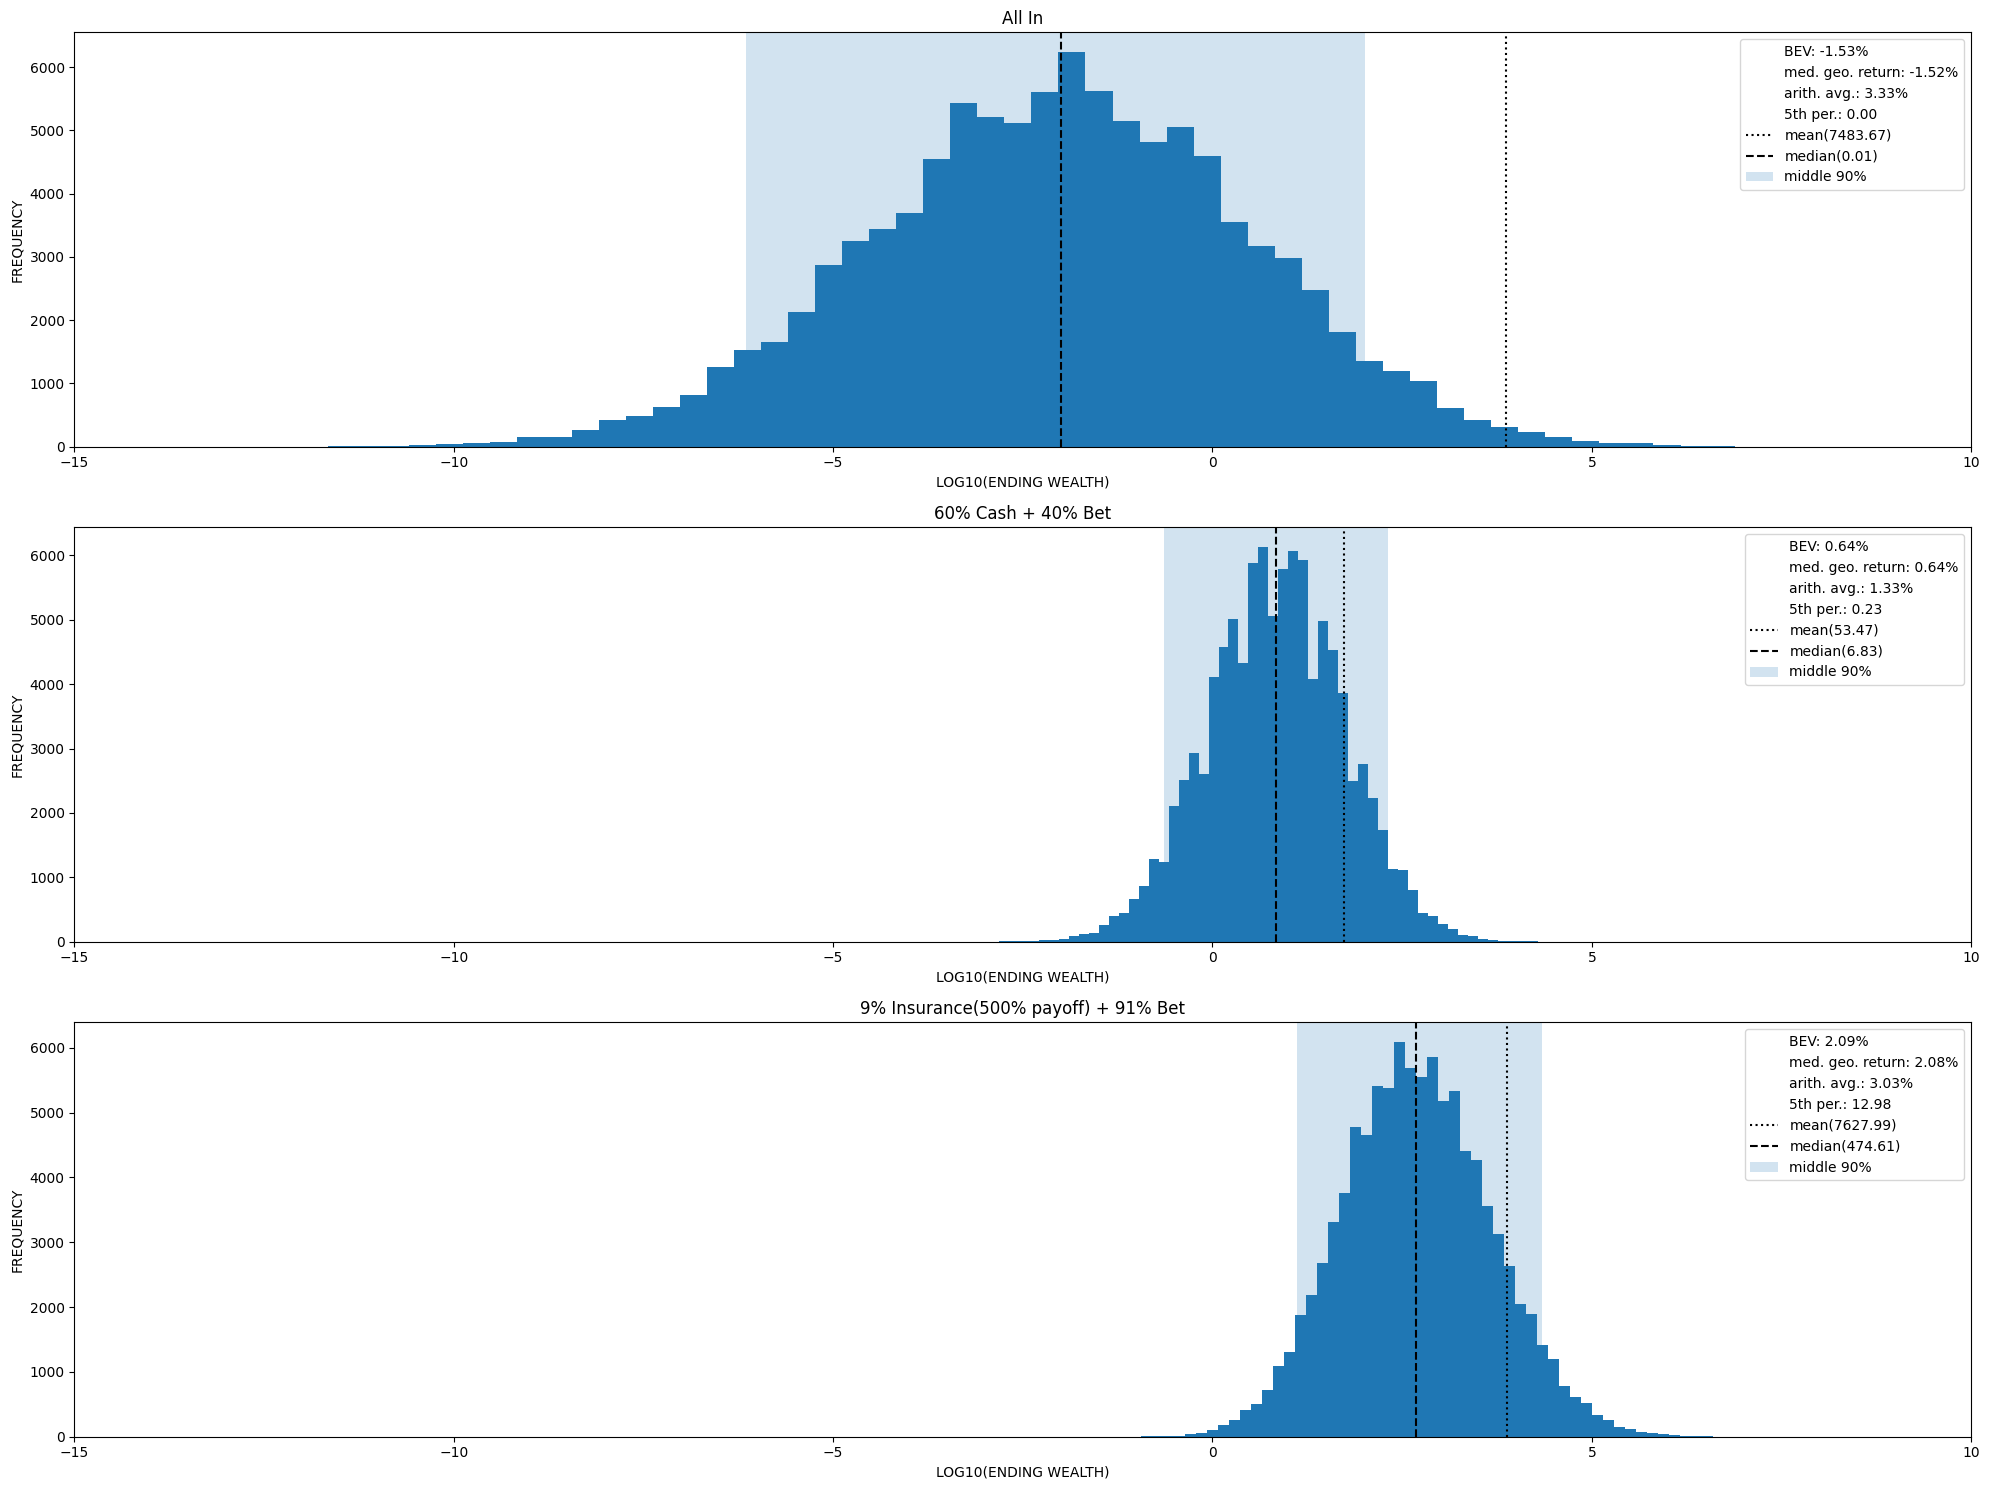

In [111]:
payoffs = np.asarray([-0.5, 0.05, 0.05, 0.05, 0.05, 0.5])

samples = 100000
bets = 300

fig, (subfig1, subfig2, subfig3) = plt.subplots(3, 1, figsize=(20, 15))

# ------- All In
ending_wealths = np.prod(1 + payoffs[np.random.randint(0, len(payoffs), (samples, bets))], axis=1)
mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.mean(np.log(1+payoffs))) - 1
median_geometric_return = median ** (1 / bets) - 1

arithmetic_avg = np.mean(1 + payoffs) - 1

subfig1.hist(ending_wealth_log, bins=60)
subfig1.set_xlim(-15, 10)
# legend-only text entries
subfig1.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig1.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig1.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig1.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f}')

subfig1.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig1.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig1.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig1.set_title("All In")
subfig1.set_xlabel("LOG10(ENDING WEALTH)")
subfig1.set_ylabel("FREQUENCY")
subfig1.legend()

# ------- 60% cash
cash_ratio = 0.6

ending_wealths = np.prod(
    (1-cash_ratio) * (1 + payoffs[np.random.randint(0, len(payoffs), (samples, bets))]) + cash_ratio,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.mean(np.log(cash_ratio+(1-cash_ratio)*(1+payoffs)))) - 1
median_geometric_return = median ** (1 / bets) - 1
arithmetic_avg = np.mean(cash_ratio + (1-cash_ratio) * (1+payoffs)) - 1

subfig2.hist(ending_wealth_log, bins=60)
subfig2.set_xlim(-15, 10)
# legend-only text entries
subfig2.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig2.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig2.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig2.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f}')

subfig2.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig2.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig2.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig2.set_title("60% Cash + 40% Bet")
subfig2.set_xlabel("LOG10(ENDING WEALTH)")
subfig2.set_ylabel("FREQUENCY")
subfig2.legend()

# ------- Insurance 9%
insurance_cost = 0.09
# this is the payoff including principal (profit = 6-1 = 500%)
insurance_payoff = 6

main_bet_returns = payoffs[np.random.randint(0, len(payoffs), (samples, bets))]
insurance_returns = np.zeros_like(main_bet_returns)
insurance_returns[main_bet_returns < 0] = insurance_payoff

ending_wealths = np.prod(
    (1-insurance_cost) * (1+main_bet_returns) + insurance_cost * insurance_returns,
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
median_geometric_return = median ** (1 / bets) - 1

insured_payoffs = np.zeros_like(payoffs)
insured_payoffs[payoffs < 0] = insurance_payoff
arithmetic_avg = np.mean(insurance_cost * insured_payoffs + (1-insurance_cost) * (1+payoffs)) - 1

bev = np.exp(np.mean(np.log((1-insurance_cost)*(payoffs+1) + insurance_cost*insured_payoffs))) - 1

subfig3.hist(ending_wealth_log, bins=60)
subfig3.set_xlim(-15, 10)
# legend-only text entries
subfig3.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig3.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig3.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig3.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f}')

subfig3.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig3.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig3.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig3.set_title("9% Insurance(500% payoff) + 91% Bet")
subfig3.set_xlabel("LOG10(ENDING WEALTH)")
subfig3.set_ylabel("FREQUENCY")
subfig3.legend()

fig.tight_layout()
plt.show()


### Optimal Kelly Bet Size
This will take a long time to run, since we are simulating runs for each bet size from 0% to 100%, so I used another sample size, `kelly_samples` in the code to speed it up.

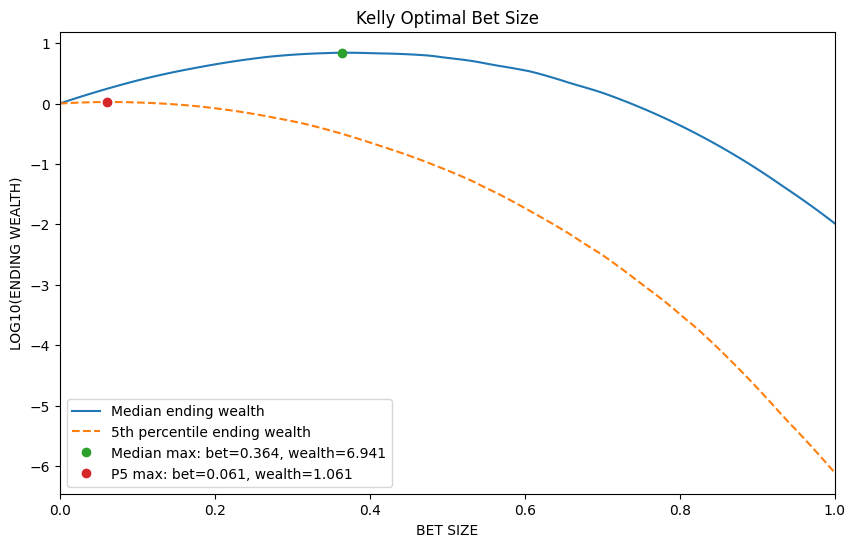

In [112]:
bet_sizes = np.linspace(0, 1, 100)

kelly_samples = 10000
# all simulation share the same random path
returns = 1 + payoffs[np.random.randint(0, len(payoffs), (kelly_samples, bets))]

bets_expanded = np.reshape(bet_sizes, (-1, 1, 1))
ending_wealths = np.prod(bets_expanded * returns + (1-bets_expanded), axis=2)
ending_wealths_medians = np.median(ending_wealths, axis=1)
ending_wealths_p5 = np.percentile(ending_wealths, 5, axis=1)

# max of median curve
idx_max_median = np.argmax(ending_wealths_medians)
best_bet_median = bet_sizes[idx_max_median]
best_value_median = ending_wealths_medians[idx_max_median]

# max of 5th percentile curve
idx_max_p5 = np.argmax(ending_wealths_p5)
best_bet_p5 = bet_sizes[idx_max_p5]
best_value_p5 = ending_wealths_p5[idx_max_p5]

plt.figure(figsize=(10,6))
plt.xlim(0, 1)
plt.plot(bet_sizes, np.log10(ending_wealths_medians),
         linestyle='solid',
         label='Median ending wealth')

plt.plot(bet_sizes, np.log10(ending_wealths_p5),
         linestyle='dashed',
         label='5th percentile ending wealth')

# mark the max points
plt.plot(best_bet_median, np.log10(best_value_median), 'o',
         label=f'Median max: bet={best_bet_median:.3f}, wealth={best_value_median:.3f}')
plt.plot(best_bet_p5, np.log10(best_value_p5), 'o',
         label=f'P5 max: bet={best_bet_p5:.3f}, wealth={best_value_p5:.3f}')

plt.xlabel("BET SIZE")
plt.ylabel("LOG10(ENDING WEALTH)")
plt.title("Kelly Optimal Bet Size")
plt.legend()

plt.show()

## Optimal Insurance Bet Size

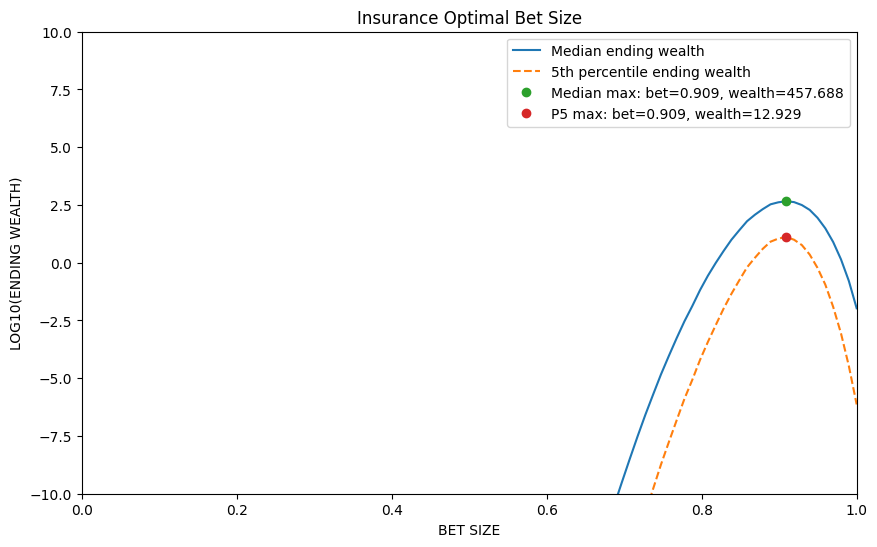

In [115]:
bet_sizes = np.linspace(0, 1, 100)
eps = 1e-12

insurance_samples = 10000
# all simulation share the same random path
main_bet_returns = payoffs[np.random.randint(0, len(payoffs), (insurance_samples, bets))]

insured_payoffs = np.zeros_like(main_bet_returns)
insured_payoffs[main_bet_returns < 0] = insurance_payoff

bets_expanded = np.reshape(bet_sizes, (-1, 1, 1))
ending_wealths = np.prod(bets_expanded * (1+main_bet_returns) + (1-bets_expanded) * insured_payoffs, axis=2)

ending_wealths_medians = np.median(ending_wealths, axis=1)
ending_wealths_p5 = np.percentile(ending_wealths, 5, axis=1)

# max of median curve
idx_max_median = np.argmax(ending_wealths_medians)
best_bet_median = bet_sizes[idx_max_median]
best_value_median = ending_wealths_medians[idx_max_median]

# max of 5th percentile curve
idx_max_p5 = np.argmax(ending_wealths_p5)
best_bet_p5 = bet_sizes[idx_max_p5]
best_value_p5 = ending_wealths_p5[idx_max_p5]

plt.figure(figsize=(10,6))
plt.xlim(0, 1)
plt.ylim(-10, 10)
plt.plot(bet_sizes, np.log10(np.clip(ending_wealths_medians, eps, None)),
         linestyle='solid',
         label='Median ending wealth')

plt.plot(bet_sizes, np.log10(np.clip(ending_wealths_p5, eps, None)),
         linestyle='dashed',
         label='5th percentile ending wealth')

# mark the max points
plt.plot(best_bet_median, np.log10(best_value_median), 'o',
         label=f'Median max: bet={best_bet_median:.3f}, wealth={best_value_median:.3f}')
plt.plot(best_bet_p5, np.log10(best_value_p5), 'o',
         label=f'P5 max: bet={best_bet_p5:.3f}, wealth={best_value_p5:.3f}')

plt.xlabel("BET SIZE")
plt.ylabel("LOG10(ENDING WEALTH)")
plt.title("Insurance Optimal Bet Size")
plt.legend()

plt.show()